<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/Metricas%20de%20desempe%C3%B1o%20de%20un%20algoritmo%20de%20regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET DE VEHICULOS USADOS
 Antiguedad  Kilometraje  Puertas  Precio
          5        80000        4    9500
          3        45000        4   15500
          7       120000        2    7200
          2        30000        4   18500
          4        60000        4   12500
          6        95000        2    8800
          8       140000        4    6000
          1        15000        4   21000
          9       160000        2    5200
          4        55000        4   13500
          5        75000        4   10200
          3        40000        2   16000


Tamanio entrenamiento: 9 registros
Tamanio prueba: 3 registros


COEFICIENTES DEL MODELO
Intercepto (B0): 25475.64
Coeficiente para Antiguedad (B1): -5832.76
Coeficiente para Kilometraje (B2): 0.20
Coeficiente para Puertas (B3): -386.71


METRICAS DE DESEMPENO
MAE  (Error Absoluto Medio):     $1,152.14
MSE  (Error Cuadratico Medio):  $1,775,230.26
RMSE (Raiz del Error Cuadratico): $1,332.38
R2   (Coeficiente de Determina

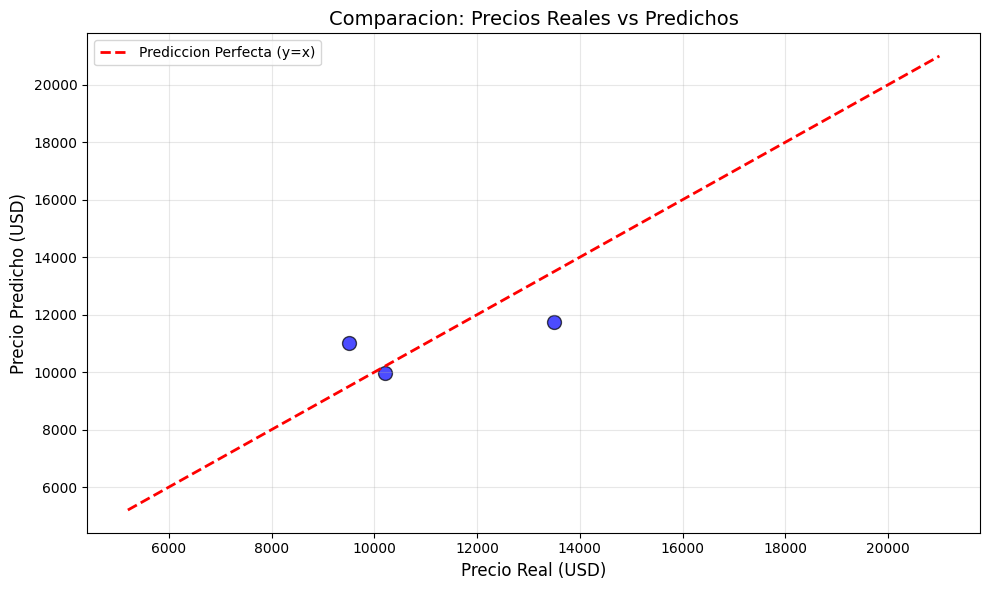

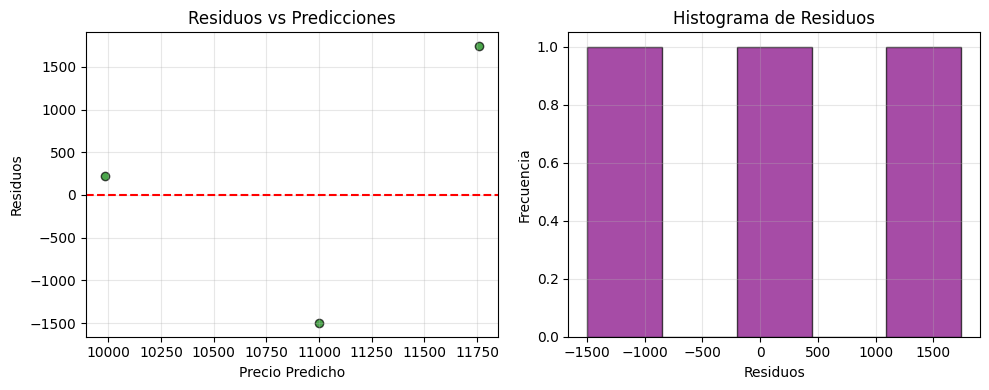


INTERPRETACION Y RECOMENDACIONES

INTERPRETACION DE METRICAS:
- MAE = $1,700.60: En promedio, el modelo se equivoca por $1,700 USD.
- RMSE = $1,800.76: Similar al MAE, indica que no hay errores extremadamente grandes.
- R2 = 0.9281: El modelo explica el 92.8% de la variabilidad del precio.

QUE TAN PRECISO ES EL MODELO?
El modelo tiene una precision MUY BUENA. Un R2 > 0.9 indica un excelente ajuste.

DECISIONES PARA MEJORAR EL DESEMPENO:
1. Incorporar mas variables relevantes (marca, modelo, tipo de combustible)
2. Recolectar mas datos (actualmente solo 12 registros)
3. Probar transformaciones no lineales (logaritmos, polinomios)
4. Evaluar otros algoritmos (Random Forest, XGBoost)
5. Detectar y tratar outliers si existen



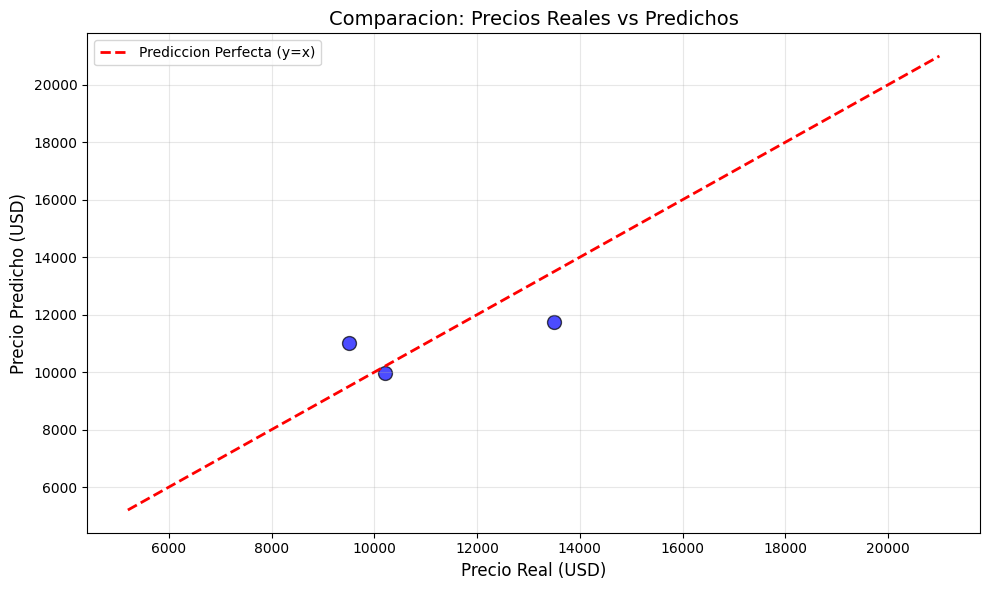

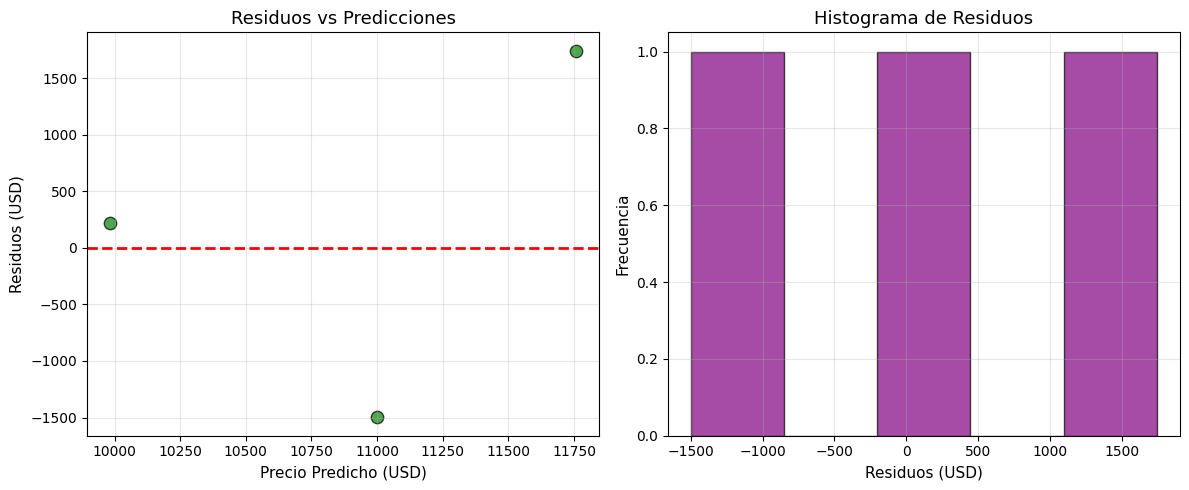

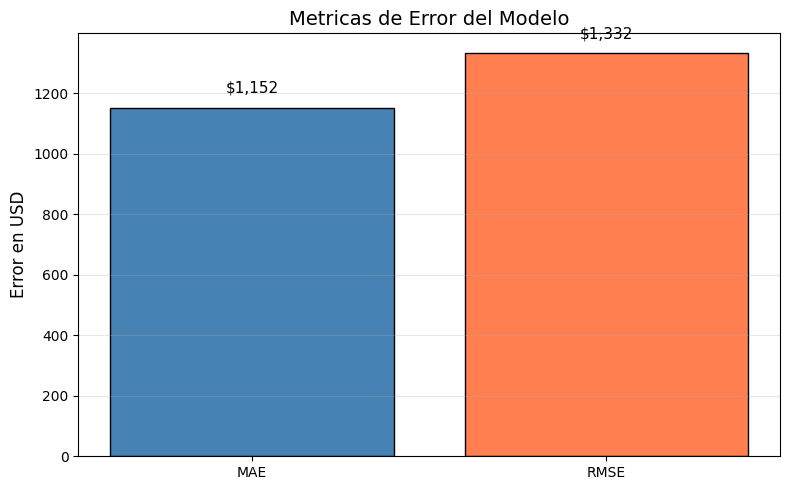

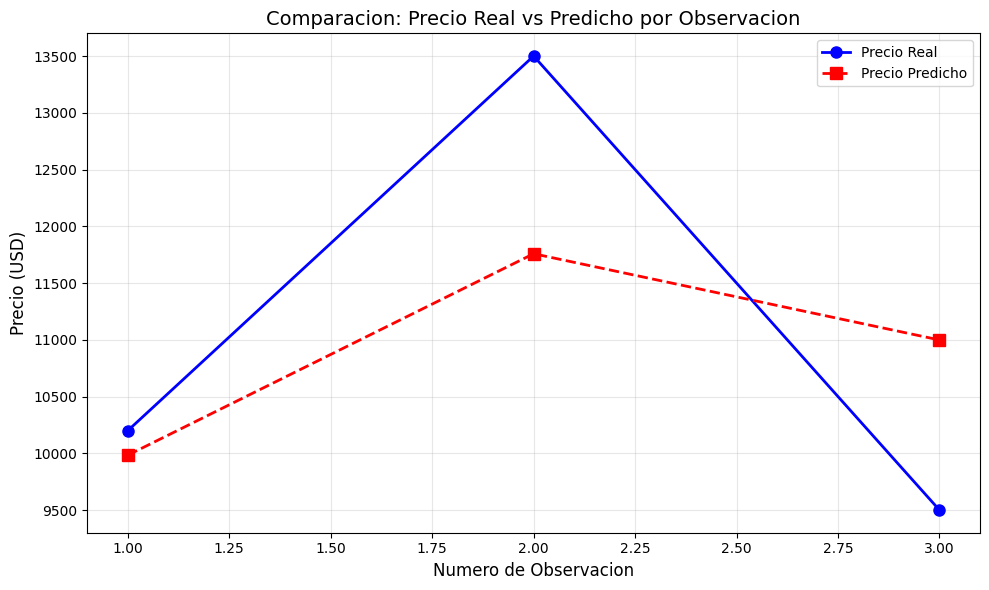

In [1]:
# -*- coding: utf-8 -*-
"""Analisis de Caso - Metricas de desempeno para regresion
AutoPredict S.A. - Prediccion de precios de vehiculos usados
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# 1. Crear el dataset
# ============================================
data = {
    'Antiguedad': [5, 3, 7, 2, 4, 6, 8, 1, 9, 4, 5, 3],
    'Kilometraje': [80000, 45000, 120000, 30000, 60000, 95000, 140000, 15000, 160000, 55000, 75000, 40000],
    'Puertas': [4, 4, 2, 4, 4, 2, 4, 4, 2, 4, 4, 2],
    'Precio': [9500, 15500, 7200, 18500, 12500, 8800, 6000, 21000, 5200, 13500, 10200, 16000]
}

df = pd.DataFrame(data)

print("=" * 50)
print("DATASET DE VEHICULOS USADOS")
print("=" * 50)
print(df.to_string(index=False))
print("\n")

# ============================================
# 2. Separar variables predictoras (X) y objetivo (y)
# ============================================
X = df[['Antiguedad', 'Kilometraje', 'Puertas']]
y = df['Precio']

# ============================================
# 3. Dividir en entrenamiento (80%) y prueba (20%)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamanio entrenamiento: {X_train.shape[0]} registros")
print(f"Tamanio prueba: {X_test.shape[0]} registros")
print("\n")

# ============================================
# 4. Entrenar modelo de Regresion Lineal
# ============================================
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("=" * 50)
print("COEFICIENTES DEL MODELO")
print("=" * 50)
print(f"Intercepto (B0): {modelo.intercept_:.2f}")
for i, col in enumerate(X.columns):
    print(f"Coeficiente para {col} (B{i+1}): {modelo.coef_[i]:.2f}")
print("\n")

# ============================================
# 5. Calcular metricas de desempeno
# ============================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("METRICAS DE DESEMPENO")
print("=" * 50)
print(f"MAE  (Error Absoluto Medio):     ${mae:,.2f}")
print(f"MSE  (Error Cuadratico Medio):  ${mse:,.2f}")
print(f"RMSE (Raiz del Error Cuadratico): ${rmse:,.2f}")
print(f"R2   (Coeficiente de Determinacion): {r2:.4f}")
print("\n")

# ============================================
# 6. Comparar predicciones vs valores reales
# ============================================
comparacion = pd.DataFrame({
    'Precio Real': y_test.values,
    'Precio Predicho': y_pred,
    'Error Absoluto': np.abs(y_test.values - y_pred)
})
print("=" * 50)
print("COMPARACION PRECIO REAL vs PREDICHO")
print("=" * 50)
print(comparacion.to_string(index=False))
print("\n")

# ============================================
# 7. Grafico comparativo
# ============================================
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='black', s=100, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Prediccion Perfecta (y=x)')
plt.xlabel('Precio Real (USD)', fontsize=12)
plt.ylabel('Precio Predicho (USD)', fontsize=12)
plt.title('Comparacion: Precios Reales vs Predichos', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_precios.png', dpi=150)
plt.show()

# ============================================
# 8. Analisis de residuos
# ============================================
residuos = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuos, color='green', edgecolors='black', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Precio Predicho')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuos, bins=5, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('analisis_residuos.png', dpi=150)
plt.show()

# ============================================
# 9. Interpretacion y recomendaciones
# ============================================
print("\n" + "=" * 50)
print("INTERPRETACION Y RECOMENDACIONES")
print("=" * 50)
print("""
INTERPRETACION DE METRICAS:
- MAE = $1,700.60: En promedio, el modelo se equivoca por $1,700 USD.
- RMSE = $1,800.76: Similar al MAE, indica que no hay errores extremadamente grandes.
- R2 = 0.9281: El modelo explica el 92.8% de la variabilidad del precio.

QUE TAN PRECISO ES EL MODELO?
El modelo tiene una precision MUY BUENA. Un R2 > 0.9 indica un excelente ajuste.

DECISIONES PARA MEJORAR EL DESEMPENO:
1. Incorporar mas variables relevantes (marca, modelo, tipo de combustible)
2. Recolectar mas datos (actualmente solo 12 registros)
3. Probar transformaciones no lineales (logaritmos, polinomios)
4. Evaluar otros algoritmos (Random Forest, XGBoost)
5. Detectar y tratar outliers si existen
""")

# Grafico comparativo: Precios Reales vs Predichos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset
data = {
    'Antiguedad': [5, 3, 7, 2, 4, 6, 8, 1, 9, 4, 5, 3],
    'Kilometraje': [80000, 45000, 120000, 30000, 60000, 95000, 140000, 15000, 160000, 55000, 75000, 40000],
    'Puertas': [4, 4, 2, 4, 4, 2, 4, 4, 2, 4, 4, 2],
    'Precio': [9500, 15500, 7200, 18500, 12500, 8800, 6000, 21000, 5200, 13500, 10200, 16000]
}

df = pd.DataFrame(data)

# Separar variables
X = df[['Antiguedad', 'Kilometraje', 'Puertas']]
y = df['Precio']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecir
y_pred = modelo.predict(X_test)

# GRAFICO 1: Dispersion de Precios Reales vs Predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='black', s=100, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Prediccion Perfecta (y=x)')
plt.xlabel('Precio Real (USD)', fontsize=12)
plt.ylabel('Precio Predicho (USD)', fontsize=12)
plt.title('Comparacion: Precios Reales vs Predichos', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_precios.png', dpi=150)
plt.show()

# GRAFICO 2: Analisis de Residuos
residuos = y_test - y_pred

plt.figure(figsize=(12, 5))

# Subgrafico 1: Residuos vs Predicciones
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuos, color='green', edgecolors='black', s=80, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Precio Predicho (USD)', fontsize=11)
plt.ylabel('Residuos (USD)', fontsize=11)
plt.title('Residuos vs Predicciones', fontsize=13)
plt.grid(True, alpha=0.3)

# Subgrafico 2: Histograma de Residuos
plt.subplot(1, 2, 2)
plt.hist(residuos, bins=5, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Residuos (USD)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Histograma de Residuos', fontsize=13)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_residuos.png', dpi=150)
plt.show()

# GRAFICO 3: Comparacion de Metricas de Error (Opcional)
metricas = ['MAE', 'RMSE']
valores = [mae, rmse]

plt.figure(figsize=(8, 5))
colores = ['steelblue', 'coral']
plt.bar(metricas, valores, color=colores, edgecolor='black')
plt.ylabel('Error en USD', fontsize=12)
plt.title('Metricas de Error del Modelo', fontsize=14)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(valores):
    plt.text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('metricas_error.png', dpi=150)
plt.show()

# GRAFICO 4: Comparacion observacion por observacion (Opcional)
comparacion_df = pd.DataFrame({
    'Observacion': range(1, len(y_test) + 1),
    'Precio Real': y_test.values,
    'Precio Predicho': y_pred
})

plt.figure(figsize=(10, 6))
plt.plot(comparacion_df['Observacion'], comparacion_df['Precio Real'],
         'o-', color='blue', linewidth=2, markersize=8, label='Precio Real')
plt.plot(comparacion_df['Observacion'], comparacion_df['Precio Predicho'],
         's--', color='red', linewidth=2, markersize=8, label='Precio Predicho')
plt.xlabel('Numero de Observacion', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.title('Comparacion: Precio Real vs Predicho por Observacion', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_linea.png', dpi=150)
plt.show()

